# Shotlist Structure Analysis — Within-Shotlist Masking
**James Baker, University of Southampton**

---

This notebook analyses structural patterns *within* shotlist fields of NLS Moving Image
Archive catalogue records. It addresses the finding from `isolate_analysis` (April 2026)
that shotlist presence is the primary differentiator between in-graph and isolate records:
90.2% of isolates contain a shotlist vs 18.2% of in-graph records.

**Core question**: Among the 76.2% of records that are isolates — many of which have rich
shotlists — do those shotlists share *structural* conventions (shot frequency, timecode
spacing, verbal formula between timecodes) that community detection on the full text
cannot detect, because the descriptive content overwhelms the structural signal?

**Masking approach** (Baker/Salway analogy, applied within fields):
- Each content word in a shotlist is replaced with the token `SLW` (shotlist word)
- Each numerical value in timecodes is replaced with `TC` (format `TC:TC` preserves separator)
- Camera direction shorthand (CU, MCU, BCU, MS, LS, GV, INT, EXT etc.) is retained verbatim
- The structural skeleton of the shotlist — how many words appear between timecodes,
  what camera notation is used, how shots are punctuated — survives masking

**Pipeline:**
- Batch A: Configuration and data loading
- Batch B: Parse shotlist fields, apply within-shotlist masking, inspect examples
- Batch C: MinHash LSH pairwise similarity on masked shotlist text
- Batch D: Leiden community detection, cross-reference with main pipeline communities
- Batch E: Cross-reference with isolate TF-IDF clusters from `isolate_analysis`

**Requires**: `RECORDS_DIR`, `COMMUNITIES_TSV` from the main `community_analysis` pipeline;
optionally `ISOLATE_CLUSTERS_TSV` from `isolate_analysis`.

**Produces**:
- `derived-data/shotlist-masked-pairwise_*.tsv`
- `derived-data/shotlist-communities_*.tsv`
- `visualisations/shotlist-structure_*.png`


## Batch A — Configuration

In [1]:
import os, re, datetime

# ── Input files ───────────────────────────────────────────────────────────────
RECORDS_DIR     = '../data/nls-moving-image-archive-2025/individual_records'

# Communities from the main pipeline (for cross-reference in Batch D)
COMMUNITIES_TSV = 'derived-data/communities_individual_records_20260417-152942.tsv'

# Isolate TF-IDF clusters from isolate_analysis (optional — for Batch E)
# Set to None if not available, or update to the path of your most recent run.
ISOLATE_CLUSTERS_TSV = 'derived-data/isolate-tfidf-clusters_20260423-173447.tsv'

# ── MinHash LSH parameters ────────────────────────────────────────────────────
# num_perm: number of hash functions. Higher = more accurate, slower.
# 128 is a good default for this corpus size.
MINHASH_NUM_PERM = 128

# LSH threshold: Jaccard similarity threshold for candidate pair generation.
# 0.5 is appropriate for short, heavily masked texts (many shared SLW tokens).
LSH_THRESHOLD = 0.5

# ── SequenceMatcher re-scoring ────────────────────────────────────────────────
# Final graph edge weight is SM ratio on the masked shotlist text (not Jaccard).
# SM captures token order (shot sequence conventions) that Jaccard does not.
GRAPH_THRESHOLD = 0.65

# Minimum number of shots (timecode occurrences) a shotlist must contain to be
# included. Excludes very short shotlists where any two records would score
# artificially high similarity after masking.
MIN_SHOTS = 2

# ── Graph / community parameters ─────────────────────────────────────────────
RESOLUTION = 1.0

# ── Output ────────────────────────────────────────────────────────────────────
DERIVED_DATA_DIR = 'derived-data'
VIS_DIR          = 'visualisations'
os.makedirs(DERIVED_DATA_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

RUN_DATETIME = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')

print(f'Records dir     : {RECORDS_DIR}')
print(f'Communities TSV : {COMMUNITIES_TSV}')
print(f'Isolate clusters: {ISOLATE_CLUSTERS_TSV}')
print(f'MinHash num_perm: {MINHASH_NUM_PERM}')
print(f'LSH threshold   : {LSH_THRESHOLD}')
print(f'Graph threshold : {GRAPH_THRESHOLD}')
print(f'Min shots       : {MIN_SHOTS}')


Records dir     : ../data/nls-moving-image-archive-2025/individual_records
Communities TSV : derived-data/communities_individual_records_20260417-152942.tsv
Isolate clusters: derived-data/isolate-tfidf-clusters_20260423-173447.tsv
MinHash num_perm: 128
LSH threshold   : 0.5
Graph threshold : 0.65
Min shots       : 2


---
## Batch B — Parse shotlist fields and apply within-shotlist masking

Extracts the SHOTLIST section from each record's `dcterms:description` fields and
applies within-shotlist masking:
- Content words → `SLW`
- Timecode digits → `TC` (format `TC:TC` preserves the colon separator)
- Camera notation shorthand (CU, MCU, BCU, MS, LS, WS, GV, INT, EXT, PAN, TILT, ZOOM
  and common plurals/variants) is retained verbatim as it encodes cataloguer practice,
  not film content.

Records with no shotlist, or with fewer than `MIN_SHOTS` timecodes, are excluded.


In [2]:
import os, re
from collections import Counter
import numpy as np

# ── Camera notation shorthand to retain verbatim ──────────────────────────────
_CAMERA_TOKENS = {
    'cu', 'mcu', 'bcu', 'ms', 'ls', 'ws', 'gv', 'int', 'ext',
    'pan', 'tilt', 'zoom', 'ha', 'la', 'ecu', 'xcu',
    'cus', 'bcus', 'mss', 'lss', 'gvs', 'ints', 'exts',
}

_RE_SHOTLIST = re.compile(r'SHOTLIST', re.IGNORECASE)
_RE_TIMECODE = re.compile(r'(\b)(\d{1,2})([:. ])(\d{2})(\b)')


def mask_shotlist_text(text):
    """
    Apply within-shotlist masking to a single shotlist field value.

    Steps:
    1. Replace timecode digit groups with TC  (e.g. 1:23 -> TC:TC).
    2. Replace all other word-tokens with SLW unless they are camera shorthand
       (retained verbatim) or already a TC token.
    """
    # Step 1: mask timecode digits; preserve separator punctuation
    masked = _RE_TIMECODE.sub(r'\1TC\3TC\5', text)
    # Step 2: tokenise and replace content words
    parts = re.split(r'(\W+)', masked)
    out = []
    for part in parts:
        lower = part.lower()
        if lower in _CAMERA_TOKENS:
            out.append(part)           # keep camera notation
        elif re.match(r'^[a-zA-Z][a-zA-Z0-9]*$', part) and lower not in ('tc', 'shotlist'):
            out.append('SLW')          # replace content word
        else:
            out.append(part)           # keep punctuation, numbers, TC, SHOTLIST
    return ''.join(out)


def extract_shotlist_fields(fpath):
    """Return list of raw shotlist field text values from one record."""
    try:
        raw = open(fpath, encoding='utf-8').read()
    except Exception:
        return []
    descs = re.findall(r'<dcterms:description>([^<]+)</dcterms:description>', raw)
    return [d.strip() for d in descs if _RE_SHOTLIST.search(d)]


def count_timecodes(text):
    """Count timecode occurrences in text (before masking)."""
    return len(_RE_TIMECODE.findall(text))


# ── Build masked shotlist dict ────────────────────────────────────────────────
print('Parsing and masking shotlist fields...')
shotlist_masked  = {}   # film_ref -> masked shotlist text
shotlist_raw     = {}   # film_ref -> raw shotlist text (for inspection)
n_has_shotlist   = 0
n_excluded_short = 0

record_files = sorted(os.listdir(RECORDS_DIR))
for i, fname in enumerate(record_files):
    if i % 5000 == 0:
        print(f'  {i:,} / {len(record_files):,}')
    stem     = os.path.splitext(fname)[0]
    film_ref = f'(filmRef){stem}'
    fpath    = os.path.join(RECORDS_DIR, fname)

    fields = extract_shotlist_fields(fpath)
    if not fields:
        continue

    n_has_shotlist += 1
    combined_raw = ' '.join(fields)
    n_tc = count_timecodes(combined_raw)

    if n_tc < MIN_SHOTS:
        n_excluded_short += 1
        continue

    shotlist_raw[film_ref]    = combined_raw
    shotlist_masked[film_ref] = mask_shotlist_text(combined_raw)

print()
print(f'Records with a shotlist field  : {n_has_shotlist:,}')
print(f'Excluded (< {MIN_SHOTS} timecodes)        : {n_excluded_short:,}')
print(f'Records available for analysis : {len(shotlist_masked):,}')
print()

# ── Masking statistics ────────────────────────────────────────────────────────
orig_lens   = [len(shotlist_raw[r])    for r in shotlist_masked]
masked_lens = [len(shotlist_masked[r]) for r in shotlist_masked]
retention   = [m / max(o, 1) for o, m in zip(orig_lens, masked_lens)]
print(f'Mean character retention after masking: {np.mean(retention):.1%}')

# ── Inspect examples ──────────────────────────────────────────────────────────
print()
print('=== MASKING EXAMPLES (5 records) ===')
sample_refs = list(shotlist_masked.keys())[::max(1, len(shotlist_masked)//5)][:5]
for ref in sample_refs:
    raw    = shotlist_raw[ref]
    masked = shotlist_masked[ref]
    print(f'\n--- {ref} ---')
    print(f'ORIGINAL : {raw[:250]}')
    print(f'MASKED   : {masked[:250]}')


Parsing and masking shotlist fields...
  0 / 23,491
  5,000 / 23,491
  10,000 / 23,491
  15,000 / 23,491
  20,000 / 23,491

Records with a shotlist field  : 17,180
Excluded (< 2 timecodes)        : 5,873
Records available for analysis : 11,307

Mean character retention after masking: 74.2%

=== MASKING EXAMPLES (5 records) ===

--- (filmRef)0001 ---
ORIGINAL : SHOTLIST: No credits. Shots of the exterior of the Botanic Gardens including the Kibble Palace (.23); Shots of tulip beds (.29); A mother pushing a pram (.35); Close-up of the child in the pram (.58); A baby girl learning to walk (1.00); Various shot
MASKED   : SHOTLIST: SLW SLW. SLW SLW SLW SLW SLW SLW SLW SLW SLW SLW SLW SLW (.23); SLW SLW SLW SLW (.29); SLW SLW SLW SLW SLW (.35); SLW-SLW SLW SLW SLW SLW SLW SLW (.58); SLW SLW SLW SLW SLW SLW (TC.TC); SLW SLW SLW SLW SLW SLW (TC.TC); SLW SLW SLW SLW SLW (

--- (filmRef)12728 ---
ORIGINAL : SHOTLIST: 00:00:10 00:55:55 01/09/1988 OCEAN ODYSSEY OIL RIG DISASTER - COMPOSITE MATERIA

---
## Batch C — MinHash LSH pairwise similarity on masked shotlist text

Uses MinHash + LSH to find candidate pairs, then recomputes SequenceMatcher ratio
on masked shotlist text for each candidate pair.

MinHash Jaccard is computed on **word 2-grams** (bigrams) of the masked text. Using
bigrams rather than unigrams preserves information about the sequence of structural
tokens (e.g. `TC:TC SLW SLW` vs `SLW TC:TC SLW`), which unigram sets would lose.
SM is then recomputed on the full masked string to capture token order within shots.

**Runtime note**: With ~23k records and LSH_THRESHOLD=0.5 this typically generates
200k–600k candidate pairs. SM recomputation on masked strings is fast (< 2 min on
this corpus; masked strings are roughly 30–40% the length of originals).


In [3]:
pip install datasketch

Note: you may need to restart the kernel to use updated packages.


Building MinHash signatures (word 2-grams)...
Built 11,307 MinHash signatures.
Running LSH (threshold=0.5)...
LSH: 809,354 candidate pairs in 1.0s
Recomputing SM on masked shotlist text...
SM recomputation: 809,354 pairs in 350.4s
Saved to: /Users/jwbaker/Library/CloudStorage/Dropbox/root/Southampton/Projects/ERC/code/derived-data/shotlist-masked-pairwise_20260423-220019.tsv


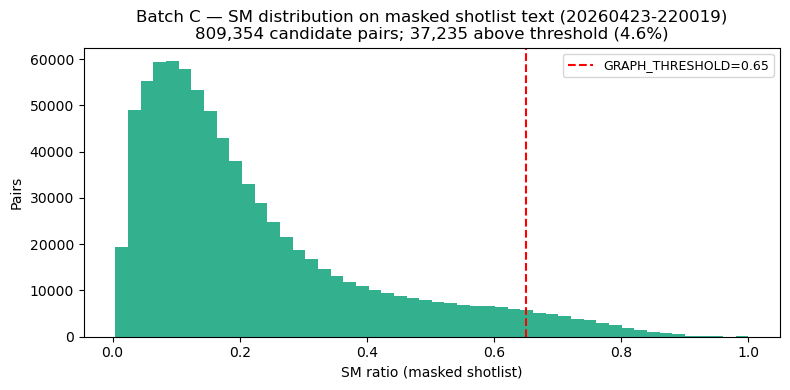

Saved: /Users/jwbaker/Library/CloudStorage/Dropbox/root/Southampton/Projects/ERC/code/visualisations/shotlist-sm-distribution_20260423-220019.png


In [4]:
try:
    from datasketch import MinHash, MinHashLSH
    _datasketch_ok = True
except ImportError:
    _datasketch_ok = False
    print('datasketch not installed. Run: pip install datasketch')

if _datasketch_ok:
    from difflib import SequenceMatcher
    import pandas as pd
    import time as _time
    import matplotlib.pyplot as plt

    # ── Build MinHash signatures on word bigrams ──────────────────────────────
    print('Building MinHash signatures (word 2-grams)...')
    minhashes = {}
    for film_ref, masked in shotlist_masked.items():
        tokens = masked.split()
        bigrams = ([f'{tokens[i]}_{tokens[i+1]}' for i in range(len(tokens) - 1)]
                   if len(tokens) > 1 else tokens)
        m = MinHash(num_perm=MINHASH_NUM_PERM)
        for bg in bigrams:
            m.update(bg.encode('utf8'))
        minhashes[film_ref] = m
    print(f'Built {len(minhashes):,} MinHash signatures.')

    # ── LSH candidate generation ──────────────────────────────────────────────
    print(f'Running LSH (threshold={LSH_THRESHOLD})...')
    _t0  = _time.time()
    lsh  = MinHashLSH(threshold=LSH_THRESHOLD, num_perm=MINHASH_NUM_PERM)
    refs = list(minhashes.keys())
    for ref in refs:
        lsh.insert(ref, minhashes[ref])

    candidate_pairs = set()
    for ref in refs:
        neighbours = lsh.query(minhashes[ref])
        for nb in neighbours:
            if nb != ref:
                pair = tuple(sorted([ref, nb]))
                candidate_pairs.add(pair)

    elapsed_lsh = _time.time() - _t0
    print(f'LSH: {len(candidate_pairs):,} candidate pairs in {elapsed_lsh:.1f}s')

    # ── Recompute SM on masked text ───────────────────────────────────────────
    print('Recomputing SM on masked shotlist text...')
    _t1 = _time.time()
    sm_rows = []
    for base_id, compare_id in candidate_pairs:
        ta = shotlist_masked[base_id]
        tb = shotlist_masked[compare_id]
        sm = SequenceMatcher(None, ta, tb).ratio()
        sm_rows.append({'base_id': base_id, 'compare_id': compare_id, 'sm_ratio': sm})

    shotlist_pairs_df = pd.DataFrame(sm_rows)
    elapsed_sm = _time.time() - _t1
    print(f'SM recomputation: {len(shotlist_pairs_df):,} pairs in {elapsed_sm:.1f}s')

    # Save
    _pairs_path = os.path.join(DERIVED_DATA_DIR,
        f'shotlist-masked-pairwise_{RUN_DATETIME}.tsv')
    shotlist_pairs_df.to_csv(_pairs_path, sep='\t', index=False)
    print(f'Saved to: {os.path.abspath(_pairs_path)}')

    # ── Distribution ─────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(shotlist_pairs_df['sm_ratio'], bins=50, color='#009E73', alpha=0.8)
    ax.axvline(GRAPH_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
               label=f'GRAPH_THRESHOLD={GRAPH_THRESHOLD}')
    _above = (shotlist_pairs_df['sm_ratio'] >= GRAPH_THRESHOLD).sum()
    ax.set_title(
        f'Batch C — SM distribution on masked shotlist text ({RUN_DATETIME})\n'
        f'{len(shotlist_pairs_df):,} candidate pairs; '
        f'{_above:,} above threshold ({_above/len(shotlist_pairs_df):.1%})'
    )
    ax.set_xlabel('SM ratio (masked shotlist)'); ax.set_ylabel('Pairs')
    ax.legend(fontsize=9)
    plt.tight_layout()
    _cplot = os.path.join(VIS_DIR, f'shotlist-sm-distribution_{RUN_DATETIME}.png')
    plt.savefig(_cplot, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {os.path.abspath(_cplot)}')


---
## Batch D — Community detection and cross-reference with main pipeline

Builds a graph from the shotlist-masked SM scores, runs Leiden, and compares the
resulting communities to those from the main `community_analysis` pipeline.

**Interpretation note**: Records in the main pipeline graph that also appear here were
in-graph records with shotlists. A high NMI would suggest that shotlist structure alone
drives their community assignment — the main communities are primarily shotlist-structure
communities. A low NMI for those records would suggest that the non-shotlist parts of
their descriptions (narrative description, credit lines) play an important role.

The more important result is the *new* communities containing **isolate records** — these
are records that were isolates in the main pipeline but now cluster together on the basis
of shared shotlist structure. These represent cataloguing practice communities that the
original SM-on-full-text approach missed.


In [5]:
import sys, os
import networkx as nx
import pandas as pd

_nb_dir = os.path.dirname(os.path.abspath('__file__'))
if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

from community_utils import run_leiden, compare_partitions

if 'shotlist_pairs_df' not in dir():
    print('Run Batch C first to generate shotlist_pairs_df.')
else:
    # ── Build graph ───────────────────────────────────────────────────────────
    edges = shotlist_pairs_df[shotlist_pairs_df['sm_ratio'] >= GRAPH_THRESHOLD]
    G_shl = nx.from_pandas_edgelist(
        edges, source='base_id', target='compare_id', edge_attr='sm_ratio'
    )
    print(f'Shotlist graph: {G_shl.number_of_nodes():,} nodes, '
          f'{G_shl.number_of_edges():,} edges')

    # ── Run Leiden (falls back to Louvain if leidenalg not installed) ─────────
    _shl_comm_path = os.path.join(DERIVED_DATA_DIR,
        f'shotlist-communities_{RUN_DATETIME}.tsv')
    shl_partition = run_leiden(
        G_shl, 'sm_ratio', _shl_comm_path,
        label='shotlist', resolution=RESOLUTION
    )

    # ── Cross-reference with main pipeline communities ────────────────────────
    if COMMUNITIES_TSV and os.path.exists(COMMUNITIES_TSV):
        orig_comm_df = pd.read_csv(COMMUNITIES_TSV, sep='\t')
        orig_part    = dict(zip(orig_comm_df['film_ref'], orig_comm_df['community_id']))

        print(f'Records in main graph     : {len(orig_part):,}')
        print(f'Records in shotlist graph : {len(shl_partition):,}')
        print()

        compare_partitions(orig_part, shl_partition,
                           label='shotlist vs main pipeline')

        # What fraction of shotlist-graph nodes were isolates in the main pipeline?
        main_graph_refs = set(orig_part.keys())
        shl_graph_refs  = set(shl_partition.keys())
        n_was_isolate   = sum(1 for r in shl_graph_refs if r not in main_graph_refs)
        n_was_in_graph  = sum(1 for r in shl_graph_refs if r in main_graph_refs)
        print()
        print(f'Shotlist-graph nodes that were isolates in the main pipeline: '
              f'{n_was_isolate:,} ({n_was_isolate/len(shl_graph_refs):.1%})')
        print(f'Shotlist-graph nodes that were in-graph in the main pipeline: '
              f'{n_was_in_graph:,} ({n_was_in_graph/len(shl_graph_refs):.1%})')
        print()
        print('Interpretation:')
        print('  High isolate fraction -> shotlist masking is revealing communities that')
        print('    the main pipeline could not detect (shotlist content overwhelmed structure).')
        print('  Low isolate fraction  -> shotlist communities largely recapitulate main communities.')


Shotlist graph: 2,403 nodes, 37,235 edges
Leiden (shotlist): 50 communities
Modularity Q: 0.5027
Saved communities to: /Users/jwbaker/Library/CloudStorage/Dropbox/root/Southampton/Projects/ERC/code/derived-data/shotlist-communities_20260423-220019.tsv
Records in main graph     : 5,585
Records in shotlist graph : 2,403

NMI COMPARISON: original vs shotlist vs main pipeline
  Records in common  : 67
  NMI                : 0.8977

  Verdict: ROBUST — communities driven by structural convention.

  Per-community stability (top 15 original communities by size):
  Community         n   stability  interpretation
  -------------------------------------------------------
  C127             5      80.0%  stable
  C27              4     100.0%  stable
  C4               4      50.0%  partial
  C245             3     100.0%  stable
  C247             3     100.0%  stable
  C248             3      66.7%  partial
  C249             3     100.0%  stable
  C306             3      66.7%  partial
  C310

---
## Batch E — Cross-reference with isolate TF-IDF clusters

Compares the shotlist-structure communities (Batch D) to the TF-IDF content clusters
from `isolate_analysis`. This addresses the question: do the structural shotlist
communities correspond to, or cut across, the content communities identified by
TF-IDF clustering?

- **High overlap** (shotlist community ≈ TF-IDF cluster): structure and content
  co-vary — cataloguers describing the same topic tend to use the same structural
  conventions. This is an interesting finding in its own right.
- **Low overlap**: structural conventions are shared across different content areas —
  the shotlist structure is a genuine practice community signal independent of subject.

Requires `ISOLATE_CLUSTERS_TSV` to be set in the configuration cell (Batch A).
If not available, re-run `isolate_analysis_v2.ipynb` and export the cluster assignments.


In [6]:
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score
from collections import Counter

if ISOLATE_CLUSTERS_TSV is None:
    print('ISOLATE_CLUSTERS_TSV is not set — skipping Batch E.')
    print('Set it in the Batch A configuration cell and re-run.')
elif not os.path.exists(ISOLATE_CLUSTERS_TSV):
    print(f'File not found: {ISOLATE_CLUSTERS_TSV}')
    print('Check the path and re-run.')
elif 'shl_partition' not in dir():
    print('Run Batch D first to generate shl_partition.')
else:
    clusters_df = pd.read_csv(ISOLATE_CLUSTERS_TSV, sep='\t')
    cluster_map = dict(zip(clusters_df['film_ref'], clusters_df['tfidf_cluster']))

    common = sorted(set(shl_partition.keys()) & set(cluster_map.keys()))
    if not common:
        print('No records in common between shotlist communities and isolate TF-IDF clusters.')
        print('(Expected if Batch D records are mostly in-graph records, not isolates.)')
    else:
        y_shl     = [shl_partition[r] for r in common]
        y_cluster = [cluster_map[r]   for r in common]
        nmi = normalized_mutual_info_score(y_cluster, y_shl, average_method='arithmetic')

        print('=' * 60)
        print('NMI: isolate TF-IDF clusters vs shotlist-structure communities')
        print('=' * 60)
        print(f'  Records in common  : {len(common):,}')
        print(f'  NMI                : {nmi:.4f}')
        print()
        if nmi >= 0.60:
            print('  Structure and content co-vary substantially: cataloguers describing')
            print('  the same topic tend to use the same shotlist conventions.')
        else:
            print('  Structure and content are largely independent: shotlist conventions')
            print('  cut across subject-matter clusters. This supports the interpretation')
            print('  that shotlist structure reflects cataloguing practice, not film content.')

        # Contingency: top shotlist communities x TF-IDF clusters
        print()
        print('  Contingency: top-10 shotlist communities x most common TF-IDF cluster')
        print(f'  {"SHL community":<16} {"n":>5}  {"top cluster":>12}  {"overlap%":>9}')
        print('  ' + '-' * 50)
        shl_comm_counter = Counter(y_shl)
        for comm, n in shl_comm_counter.most_common(10):
            idxs       = [i for i, c in enumerate(y_shl) if c == comm]
            this_clust = [y_cluster[i] for i in idxs]
            top_cl, top_n = Counter(this_clust).most_common(1)[0]
            print(f'  SHL-{comm:<12} {n:>5}  cluster {top_cl:>4}  {top_n/n:>8.1%}')


NMI: isolate TF-IDF clusters vs shotlist-structure communities
  Records in common  : 2,336
  NMI                : 0.2162

  Structure and content are largely independent: shotlist conventions
  cut across subject-matter clusters. This supports the interpretation
  that shotlist structure reflects cataloguing practice, not film content.

  Contingency: top-10 shotlist communities x most common TF-IDF cluster
  SHL community        n   top cluster   overlap%
  --------------------------------------------------
  SHL-0              610  cluster    1     28.0%
  SHL-1              567  cluster   14     19.0%
  SHL-2              425  cluster   12     82.1%
  SHL-3              302  cluster   12     27.2%
  SHL-4              152  cluster    1     21.7%
  SHL-5              103  cluster    9     26.2%
  SHL-6               30  cluster   11    100.0%
  SHL-8               30  cluster    1     23.3%
  SHL-7               28  cluster   15     96.4%
  SHL-9               16  cluster    1     4